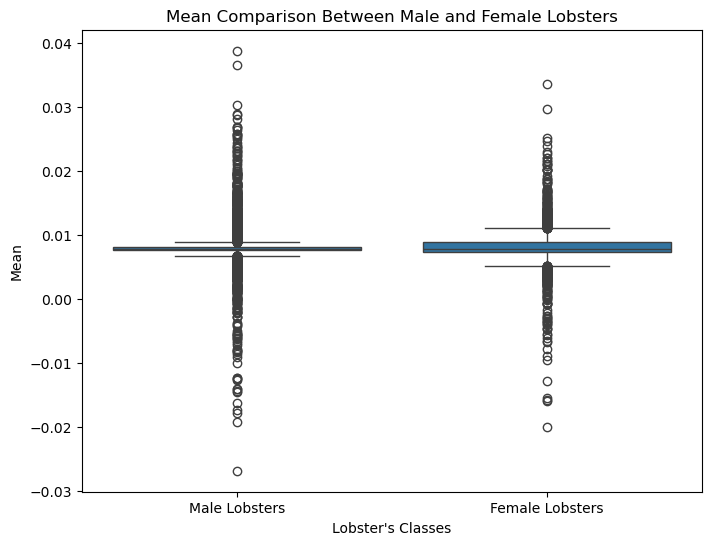

                   Mean                                                    \
                  count      mean       std       min       25%       50%   
Folder                                                                      
Female Lobsters  2900.0  0.008178  0.002884 -0.019894  0.007405  0.007919   
Male Lobsters    4407.0  0.008036  0.003146 -0.026788  0.007615  0.007813   

                                     
                      75%       max  
Folder                               
Female Lobsters  0.008888  0.033558  
Male Lobsters    0.008155  0.038811  


In [7]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

def calculate_mean_and_create_boxplot(audio_folders, folder_names):
    """Calculates mean for audio segments in multiple folders and creates a box plot.

    Args:
        audio_folders: A list of paths to the audio folders.
        folder_names: A list of names corresponding to each folder (for labels).
    """

    data = []
    labels = []

    for i, audio_folder in enumerate(audio_folders):
        mean_values = []
        for filename in os.listdir(audio_folder):
            if filename.endswith(('.wav', '.mp3', '.flac')):
                audio_file = os.path.join(audio_folder, filename)
                try:
                    y, sr = librosa.load(audio_file, duration=1.0)

                    if len(y) != sr:
                        print(f"Warning: {filename} in {folder_names[i]} is not exactly 1 second long. It is {len(y)/sr} seconds long")

                    mean = np.mean(y)  # Calculate the mean
                    mean_values.append(mean)

                except Exception as e:
                    print(f"Error processing {filename} in {folder_names[i]}: {e}")

        data.extend(mean_values)
        labels.extend([folder_names[i]] * len(mean_values))

    if not data:
        print("No valid audio files found in any of the folders or errors occurred during processing.")
        return

    df = pd.DataFrame({'Folder': labels, 'Mean': data})  # Changed column name to 'Mean'

    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Folder', y='Mean', data=df)  # Changed y-axis to 'Mean'
    plt.xlabel("Lobster's Classes")
    plt.ylabel("Mean")  # Changed y-axis label
    plt.title("Mean Comparison Between Male and Female Lobsters")  # Changed title
    plt.show()

    print(df.groupby('Folder').describe())

# Example usage (same as before):
audio_folders = [
    "/home/feliciano/male_lobsters",
    "/home/feliciano/female_lobsters",
]
folder_names = ["Male Lobsters", "Female Lobsters"]

calculate_mean_and_create_boxplot(audio_folders, folder_names)